In [ ]:
# Problem 1

## Aim
To perform manual histogram equalization on a 4-bit grayscale image matrix.

## Theory
Histogram Equalization enhances image contrast by redistributing pixel intensities over the available intensity range. For a 4-bit image, gray levels range from 0 to 15.

## Algorithm
1. Read the image matrix.
2. Calculate histogram.
3. Compute PDF.
4. Compute CDF.
5. Generate transformation table.
6. Map original pixels.
7. Display results.

Histogram:
[0. 0. 1. 2. 2. 1. 1. 2. 1. 1. 2. 1. 1. 1. 0. 0.]

Transformation:
[ 0  0  1  3  5  6  7  8  9 10 12 13 14 15 15 15]

Equalized Image:
[[ 1  3  3  5]
 [ 5  6  7  8]
 [ 8  9 10 12]
 [12 13 14 15]]


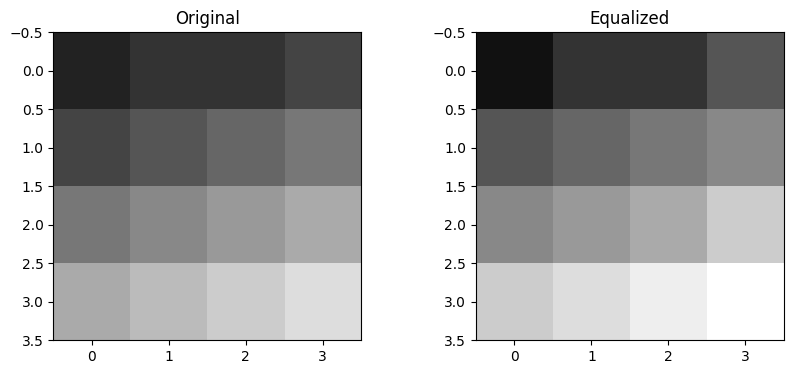

In [1]:
import numpy as np
import matplotlib.pyplot as plt

image = np.array([
    [2,3,3,4],
    [4,5,6,7],
    [7,8,9,10],
    [10,11,12,13]
], dtype=np.uint8)

L = 16

hist = np.zeros(L)

for pixel in image.flatten():
    hist[pixel] += 1

pdf = hist / image.size
cdf = np.cumsum(pdf)

transform = np.round((L-1) * cdf).astype(np.uint8)

equalized = transform[image]

print("Histogram:")
print(hist)

print("\nTransformation:")
print(transform)

print("\nEqualized Image:")
print(equalized)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image,cmap='gray',vmin=0,vmax=15)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(equalized,cmap='gray',vmin=0,vmax=15)
plt.title("Equalized")

plt.show()

In [ ]:
## Result

Histogram equalization successfully improved the contrast of the 4-bit image by redistributing intensity values.

In [ ]:
# Problem 2

## Aim
To perform negative and logarithmic transformations on a grayscale image.

## Theory
Negative transformation inverts pixel intensities. Log transformation expands dark pixel values and compresses brighter regions.

## Algorithm
1. Read grayscale image.
2. Compute negative transformation.
3. Compute log transformation.
4. Display outputs.

/tmp/ipykernel_1121/3470086809.py:12: RuntimeWarning: overflow encountered in scalar add
  c = 255/np.log(1+np.max(image))
/tmp/ipykernel_1121/3470086809.py:12: RuntimeWarning: divide by zero encountered in log
  c = 255/np.log(1+np.max(image))


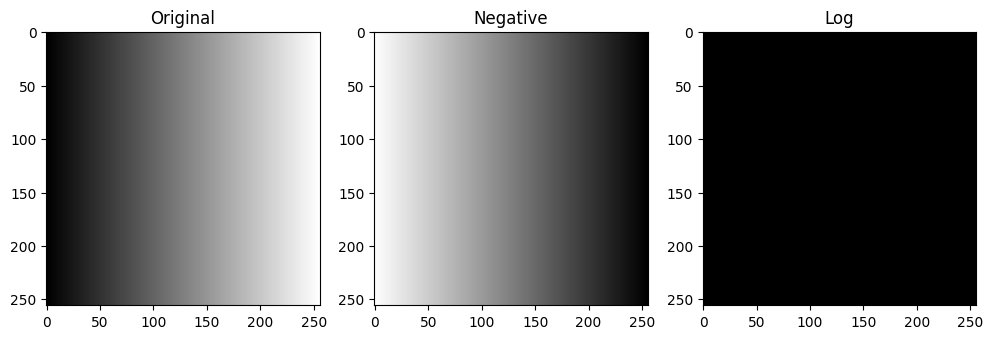

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.tile(np.arange(256,dtype=np.uint8),(256,1))

negative = 255-image

c = 255/np.log(1+np.max(image))
log_image = c*np.log(1+image.astype(np.float32))
log_image = np.array(log_image,dtype=np.uint8)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image,cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(negative,cmap='gray')
plt.title("Negative")

plt.subplot(1,3,3)
plt.imshow(log_image,cmap='gray')
plt.title("Log")

plt.show()

In [ ]:
## Result

Negative transformation inverted the grayscale image, while logarithmic transformation enhanced darker regions.

In [ ]:
# Problem 3

## Aim
To study the effect of gamma values on image contrast.

## Theory
Gamma correction adjusts image brightness using the power-law equation.

## Algorithm
1. Read image.
2. Apply gamma values.
3. Display outputs.

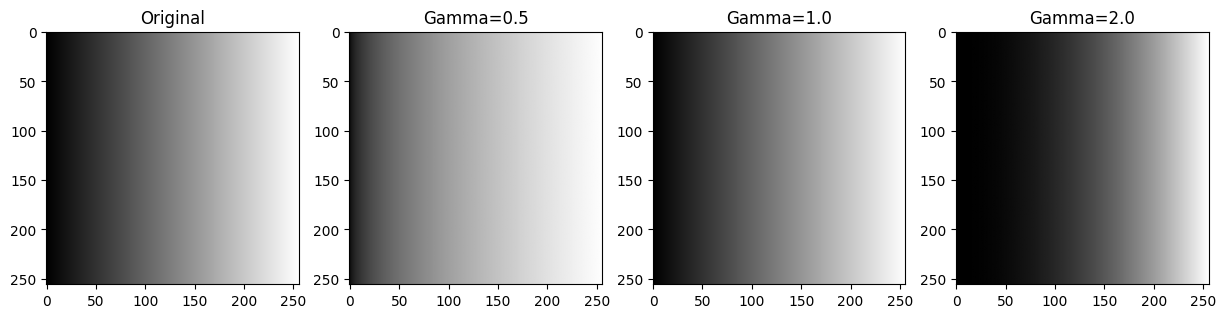

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.tile(np.arange(256,dtype=np.uint8),(256,1))

gammas = [0.5,1.0,2.0]

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(image,cmap='gray')
plt.title("Original")

for i,gamma in enumerate(gammas):

    corrected = np.power(image/255.0,gamma)
    corrected = np.uint8(corrected*255)

    plt.subplot(1,4,i+2)
    plt.imshow(corrected,cmap='gray')
    plt.title(f"Gamma={gamma}")

plt.show()

In [ ]:
## Result

Negative transformation inverted the grayscale image, while logarithmic transformation enhanced darker regions.

In [ ]:
# Problem 3

## Aim
To study the effect of gamma values on image contrast.

## Theory
Gamma correction adjusts image brightness using the power-law equation.

## Algorithm
1. Read image.
2. Apply gamma values.
3. Display outputs.

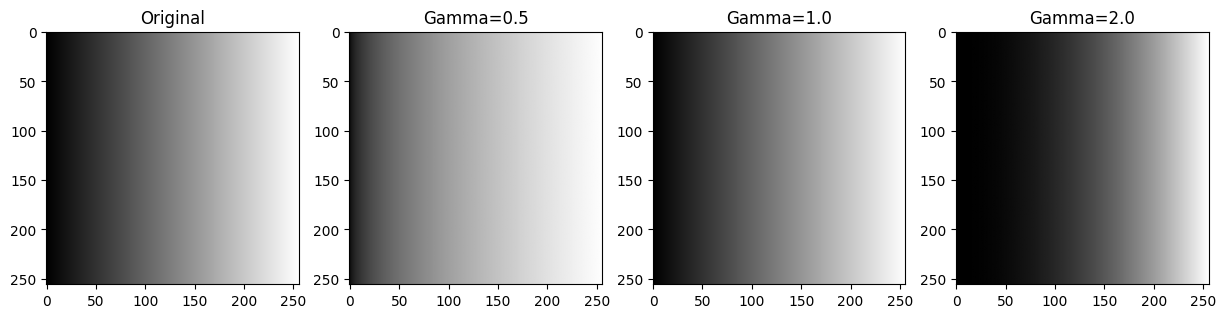

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.tile(np.arange(256,dtype=np.uint8),(256,1))

gammas = [0.5,1.0,2.0]

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(image,cmap='gray')
plt.title("Original")

for i,gamma in enumerate(gammas):

    corrected = np.power(image/255.0,gamma)
    corrected = np.uint8(corrected*255)

    plt.subplot(1,4,i+2)
    plt.imshow(corrected,cmap='gray')
    plt.title(f"Gamma={gamma}")

plt.show()

In [ ]:
## Result

Gamma values less than 1 brighten the image, whereas values greater than 1 darken it.

In [ ]:
# Problem 4

## Aim
To improve image contrast using piecewise linear contrast stretching.

## Theory
Contrast stretching expands a selected intensity range while compressing the remaining regions.

## Algorithm
1. Read image.
2. Define break points.
3. Apply piecewise mapping.
4. Display results.

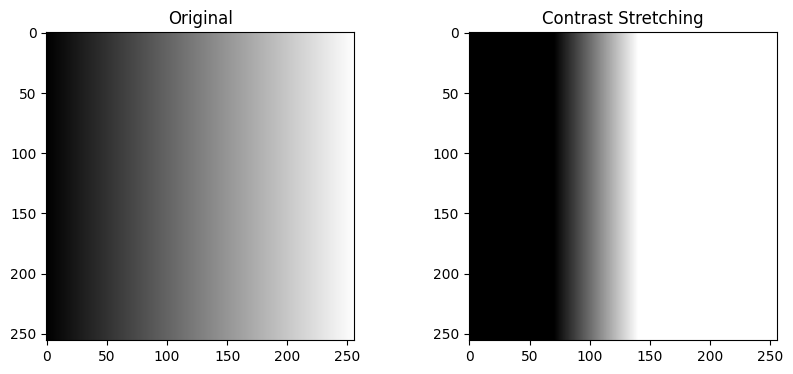

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.tile(np.arange(256,dtype=np.uint8),(256,1))

r1,s1 = 70,0
r2,s2 = 140,255

output = np.zeros_like(image)

for i in range(image.shape[0]):
    for j in range(image.shape[1]):

        r = image[i,j]

        if r<r1:
            output[i,j]=(s1/r1)*r

        elif r<=r2:
            output[i,j]=((s2-s1)/(r2-r1))*(r-r1)+s1

        else:
            output[i,j]=((255-s2)/(255-r2))*(r-r2)+s2

output=np.uint8(output)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(output,cmap='gray')
plt.title("Contrast Stretching")

plt.show()

In [ ]:
## Result

Piecewise linear transformation successfully enhanced the contrast of the selected intensity range.

In [ ]:
# Problem 5

## Aim
To perform image smoothing using a mean filter.

## Theory
A mean filter replaces each pixel with the average intensity of its neighboring pixels, reducing random noise.

## Algorithm
1. Read image.
2. Create averaging kernel.
3. Apply convolution.
4. Display outputs.

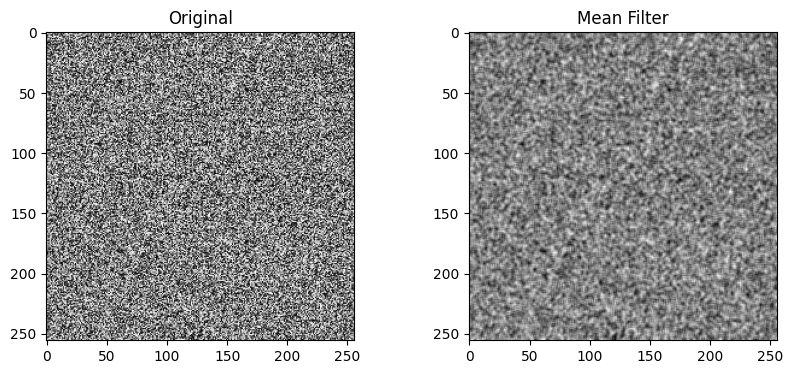

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.random.randint(0,256,(256,256),dtype=np.uint8)

kernel = np.ones((3,3),np.float32)/9

filtered = cv2.filter2D(image,-1,kernel)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(filtered,cmap='gray')
plt.title("Mean Filter")

plt.show()

In [ ]:
## Result

The mean filter smoothed the image by reducing noise while slightly blurring edges.

In [ ]:
# Problem 6

## Aim
To remove salt-and-pepper noise from an image using a median filter.

## Theory
The median filter is a non-linear filtering technique that replaces each pixel with the median value of its neighboring pixels. It effectively removes impulse noise while preserving image edges.

## Algorithm
1. Read the grayscale image.
2. Add salt-and-pepper noise.
3. Apply the median filter.
4. Display the original, noisy, and filtered images.

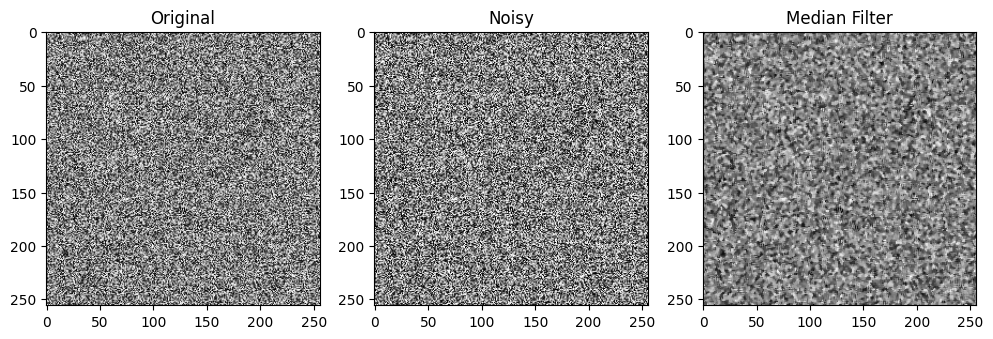

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg", 0)

if image is None:
    image = np.random.randint(0, 256, (256,256), dtype=np.uint8)

noisy = image.copy()

prob = 0.05

salt = np.random.rand(*image.shape) < prob
pepper = np.random.rand(*image.shape) < prob

noisy[salt] = 255
noisy[pepper] = 0

filtered = cv2.medianBlur(noisy, 3)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")

plt.subplot(1,3,3)
plt.imshow(filtered, cmap='gray')
plt.title("Median Filter")

plt.show()

In [ ]:
## Result

The median filter successfully removed salt-and-pepper noise while preserving image edges better than the mean filter.

In [ ]:
# Problem 7

## Aim
To sharpen an image using the Laplacian operator.

## Theory
The Laplacian operator highlights regions with rapid intensity changes. Adding the Laplacian image to the original image produces a sharpened image.

## Algorithm
1. Read the image.
2. Compute the Laplacian.
3. Convert to absolute values.
4. Add to the original image.
5. Display the results.

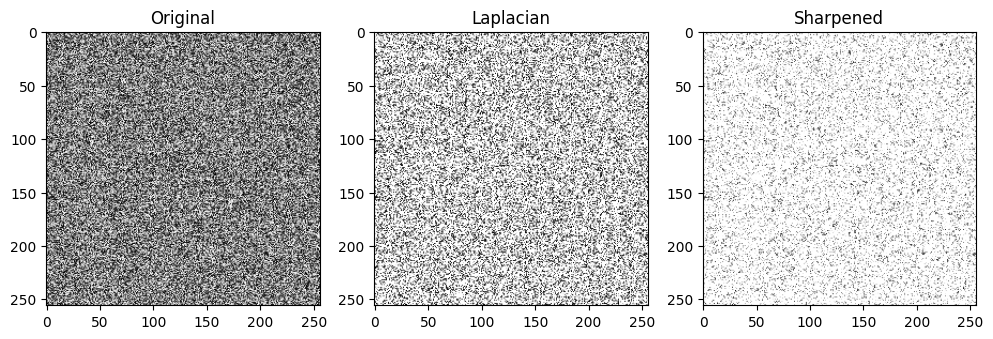

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.random.randint(0,256,(256,256),dtype=np.uint8)

lap = cv2.Laplacian(image, cv2.CV_64F)
lap = cv2.convertScaleAbs(lap)

sharp = cv2.add(image, lap)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image,cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(lap,cmap='gray')
plt.title("Laplacian")

plt.subplot(1,3,3)
plt.imshow(sharp,cmap='gray')
plt.title("Sharpened")

plt.show()

In [ ]:
## Result

Laplacian sharpening enhanced the edges and fine details of the image.

In [ ]:
# Problem 8

## Aim
To sharpen an image using high-boost filtering.

## Theory
High-boost filtering enhances image details by adding a scaled mask obtained from the difference between the original and blurred images.

## Algorithm
1. Read the image.
2. Blur the image.
3. Compute the mask.
4. Add the amplified mask.
5. Display outputs.

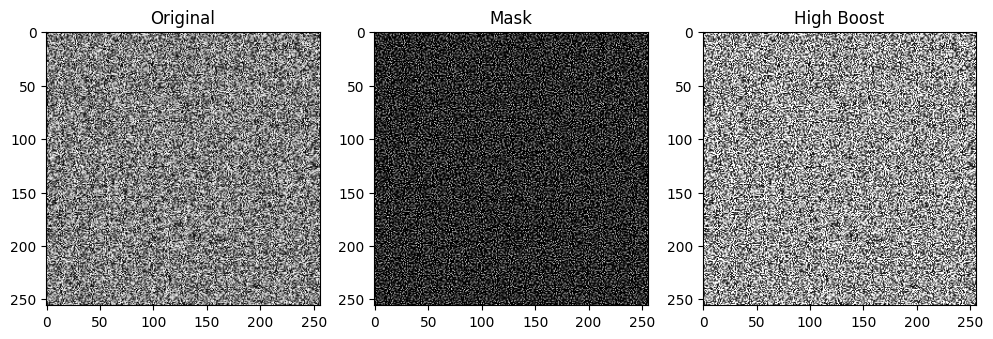

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.random.randint(0,256,(256,256),dtype=np.uint8)

blur = cv2.GaussianBlur(image,(5,5),0)

mask = cv2.subtract(image, blur)

A = 1.8

boost = cv2.add(image, np.uint8(A*mask))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image,cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(mask,cmap='gray')
plt.title("Mask")

plt.subplot(1,3,3)
plt.imshow(boost,cmap='gray')
plt.title("High Boost")

plt.show()

In [ ]:
## Result

High-boost filtering enhanced edges while maintaining the overall appearance of the original image.

In [ ]:
# Problem 9

## Aim
To remove high-frequency components using an Ideal Low-Pass Filter.

## Theory
An Ideal Low-Pass Filter preserves low-frequency components and blocks high-frequency components, resulting in a blurred image.

## Algorithm
1. Read the image.
2. Compute the Fourier Transform.
3. Create an Ideal Low-Pass Mask.
4. Perform inverse FFT.
5. Display outputs.

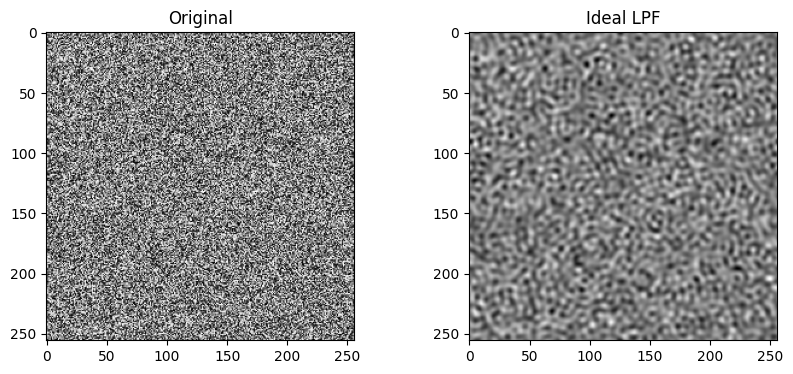

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.random.randint(0,256,(256,256),dtype=np.uint8)

dft = np.fft.fft2(image)
shift = np.fft.fftshift(dft)

rows, cols = image.shape
crow, ccol = rows//2, cols//2

mask = np.zeros((rows,cols),np.uint8)

radius = 40

Y,X = np.ogrid[:rows,:cols]

dist = np.sqrt((X-ccol)**2+(Y-crow)**2)

mask[dist<=radius]=1

filtered = shift*mask

back = np.fft.ifft2(np.fft.ifftshift(filtered))
back = np.abs(back)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(back,cmap='gray')
plt.title("Ideal LPF")

plt.show()

In [ ]:
## Result

The Ideal Low-Pass Filter successfully removed high-frequency components and blurred the image.

In [ ]:
# Problem 10

## Aim
To sharpen an image using a Gaussian High-Pass Filter.

## Theory
A Gaussian High-Pass Filter removes low-frequency components while preserving high-frequency details for edge enhancement.

## Algorithm
1. Read the image.
2. Compute FFT.
3. Create Gaussian HPF mask.
4. Apply inverse FFT.
5. Display the results.

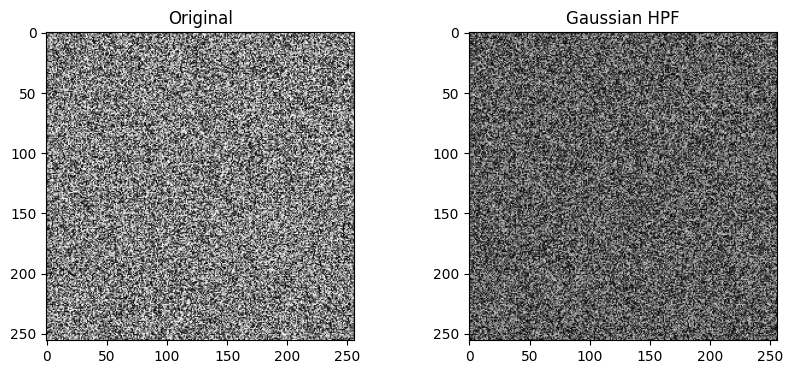

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.random.randint(0,256,(256,256),dtype=np.uint8)

rows, cols = image.shape
crow, ccol = rows//2, cols//2

dft = np.fft.fft2(image)
shift = np.fft.fftshift(dft)

D0 = 30

Y,X = np.ogrid[:rows,:cols]

distance = np.sqrt((X-ccol)**2+(Y-crow)**2)

mask = 1 - np.exp(-(distance**2)/(2*(D0**2)))

filtered = shift*mask

back = np.fft.ifft2(np.fft.ifftshift(filtered))
back = np.abs(back)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(back,cmap='gray')
plt.title("Gaussian HPF")

plt.show()

In [ ]:
## Result

The Gaussian High-Pass Filter enhanced edges and fine image details while suppressing low-frequency information.

In [ ]:
# Problem 11

## Aim
To detect isolated points in an image using a Laplacian mask.

## Theory
Point detection identifies isolated pixels whose intensity differs significantly from their neighbors. A Laplacian mask enhances these isolated points.

## Algorithm
1. Read the grayscale image.
2. Define the Laplacian mask.
3. Apply convolution.
4. Display the detected points.

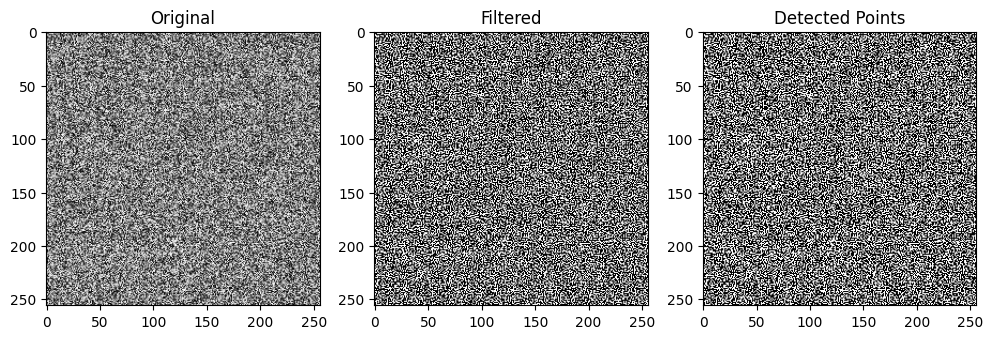

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.random.randint(0,256,(256,256),dtype=np.uint8)

kernel = np.array([
    [-1,-1,-1],
    [-1, 8,-1],
    [-1,-1,-1]
],dtype=np.float32)

points = cv2.filter2D(image,-1,kernel)

_, detected = cv2.threshold(points,120,255,cv2.THRESH_BINARY)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image,cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(points,cmap='gray')
plt.title("Filtered")

plt.subplot(1,3,3)
plt.imshow(detected,cmap='gray')
plt.title("Detected Points")

plt.show()

In [ ]:
## Result

The Laplacian mask successfully detected isolated intensity points in the image.

In [ ]:
# Problem 12

## Aim
To detect horizontal, vertical and diagonal lines using directional masks.

## Theory
Directional masks respond strongly to edges or lines aligned in a specific direction.

## Algorithm
1. Read the image.
2. Apply directional masks.
3. Display all detected line images.

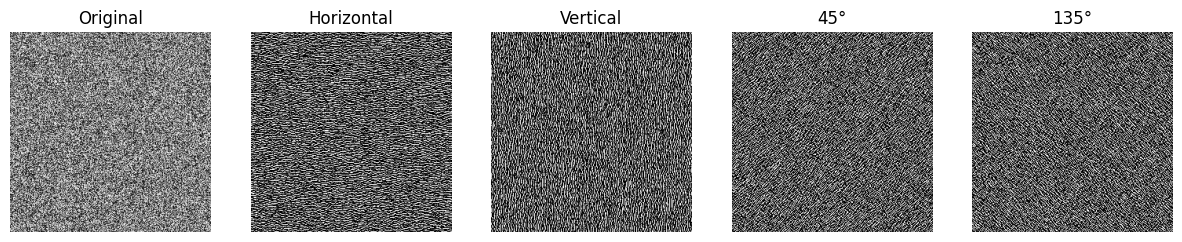

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.random.randint(0,256,(256,256),dtype=np.uint8)

horizontal = np.array([
[-1,-1,-1],
[ 2, 2, 2],
[-1,-1,-1]
],dtype=np.float32)

vertical = np.array([
[-1,2,-1],
[-1,2,-1],
[-1,2,-1]
],dtype=np.float32)

diag45 = np.array([
[-1,-1,2],
[-1,2,-1],
[2,-1,-1]
],dtype=np.float32)

diag135 = np.array([
[2,-1,-1],
[-1,2,-1],
[-1,-1,2]
],dtype=np.float32)

h = cv2.filter2D(image,-1,horizontal)
v = cv2.filter2D(image,-1,vertical)
d45 = cv2.filter2D(image,-1,diag45)
d135 = cv2.filter2D(image,-1,diag135)

titles=["Original","Horizontal","Vertical","45°","135°"]
images=[image,h,v,d45,d135]

plt.figure(figsize=(15,3))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i],cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.show()

In [ ]:
## Result

Directional masks successfully detected lines in different orientations.

In [ ]:
# Problem 13

## Aim
To segment an image using Otsu's thresholding.

## Theory
Otsu's method automatically determines the optimal threshold by maximizing between-class variance.

## Algorithm
1. Read image.
2. Apply Otsu thresholding.
3. Display segmented image.

Otsu Threshold = 127.0


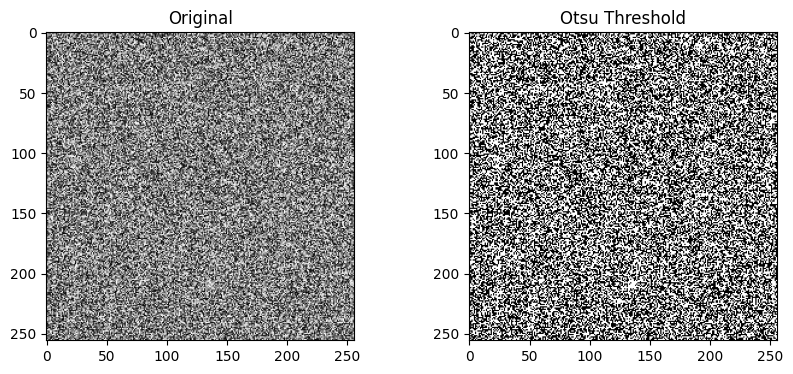

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.random.randint(0,256,(256,256),dtype=np.uint8)

threshold, otsu = cv2.threshold(
    image,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu Threshold =",threshold)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(otsu,cmap='gray')
plt.title("Otsu Threshold")

plt.show()

In [ ]:
## Result

Otsu's method automatically selected the optimum threshold and segmented the image.

In [ ]:
# Problem 14

## Aim
To segment an image using the Region Growing algorithm.

## Theory
Region Growing starts from a seed pixel and includes neighboring pixels with similar intensity values.

## Algorithm
1. Read image.
2. Select seed point.
3. Compare neighboring pixels.
4. Grow the region.
5. Display segmented region.

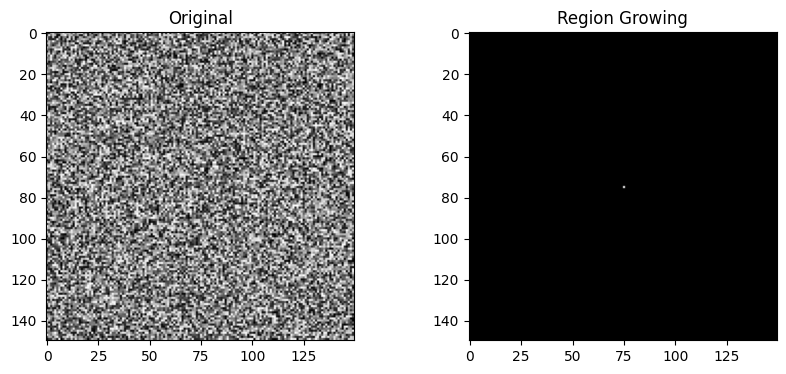

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

if image is None:
    image = np.random.randint(0,256,(150,150),dtype=np.uint8)

seed = (75,75)
threshold = 15

visited = np.zeros_like(image,dtype=bool)
region = np.zeros_like(image)

stack = [seed]

while stack:

    x,y = stack.pop()

    if x<0 or y<0 or x>=image.shape[0] or y>=image.shape[1]:
        continue

    if visited[x,y]:
        continue

    visited[x,y]=True

    if abs(int(image[x,y])-int(image[seed]))<threshold:

        region[x,y]=255

        stack.extend([
            (x+1,y),
            (x-1,y),
            (x,y+1),
            (x,y-1)
        ])

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(region,cmap='gray')
plt.title("Region Growing")

plt.show()

In [ ]:
## Result

Region Growing segmented pixels having similar intensity values from the selected seed point.

In [ ]:
# Problem 15

## Aim
To perform edge linking using the Hough Transform.

## Theory
The Hough Transform detects straight lines by transforming edge points into parameter space and linking them into continuous lines.

## Algorithm
1. Read image.
2. Detect edges using Canny.
3. Apply Hough Line Transform.
4. Draw detected lines.
5. Display results.

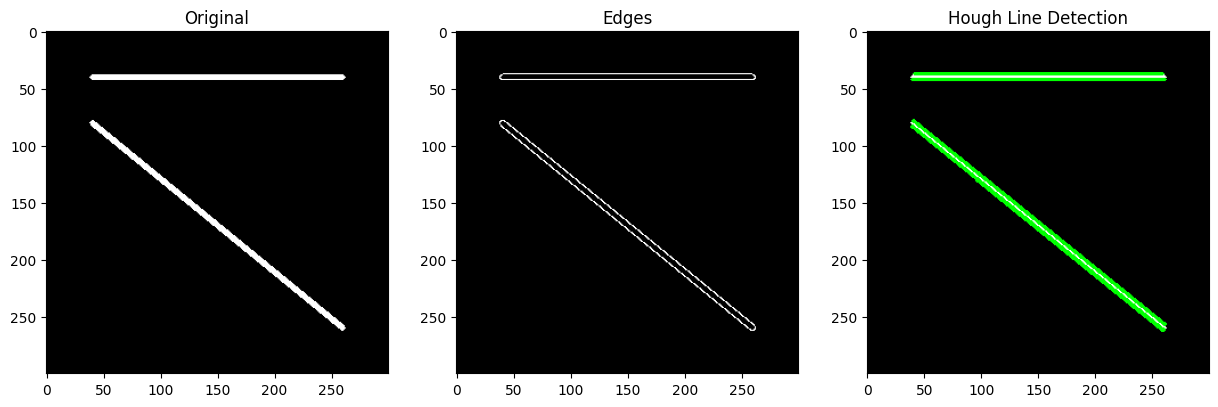

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg")

if image is None:
    image = np.zeros((300,300,3),dtype=np.uint8)
    cv2.line(image,(40,40),(260,40),(255,255,255),3)
    cv2.line(image,(40,80),(260,260),(255,255,255),3)

gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray,50,150)

lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi/180,
    threshold=60,
    minLineLength=50,
    maxLineGap=10
)

output = image.copy()

if lines is not None:
    for line in lines:
        x1,y1,x2,y2 = line
        cv2.line(output,(x1,y1),(x2,y2),(0,255,0),2)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(edges,cmap='gray')
plt.title("Edges")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(output,cv2.COLOR_BGR2RGB))
plt.title("Hough Line Detection")

plt.show()

In [ ]:
## Result

The Hough Transform successfully linked edge pixels into straight lines and detected prominent line segments in the image.